# BLG 307 - Yapay Zeka Sistemleri Proje 1
## Genetik Algoritma ile Optimizasyon (Senaryo 7)

* **Adı:** Muhammed Emin
* **Soyadı:** Oshan
* **Okul No:** 2212729007
* **Senaryo:** Laboratuvarda Numune Karışımı
* **GitHub Repo:**https://github.com/eminoshan/Genetik-Algoritma-Odev/edit/main/Proje1_Senaryo7.ipynb

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- PARAMETRELER VE SENARYO 7 TANIMI ---
# Senaryo 7: Laboratuvarda Numune Karışımı 
# Amaç Fonksiyonu: y = 3x1 + 2x2 + x1*x2 - 0.5*x2^2
# Değişkenler: x1 (Reaktif A, %10-80), x2 (Reaktif B, %10-80)

POPULATION_SIZE = 50       
GENERATIONS = 50          
MUTATION_RATE = 0.1
ELITISM_COUNT = 2             # En iyi 2 bireyi koruyacağız
BOUNDS = [(10, 80), (10, 80)] # x1 ve x2 sınırları (Min, Max)

In [2]:
# --- UYGUNLUK (FITNESS) FONKSİYONU ---
def fitness_function(individual):
    x1 = individual[0]
    x2 = individual[1]
    
    # Kısıtları kontrol et ve CEZA (Penalty) uygula
    penalty = 0
    
    # Kısıt 1: x1 + x2 <= 100
    if (x1 + x2) > 100:
        # İhlal miktarı kadar ceza veriyoruz (5000 sabit + ihlal * 100)
        penalty += 5000 + (x1 + x2 - 100) * 100
        
    # Kısıt 2: x1 >= 25
    if x1 < 25:
        penalty += 5000 + (25 - x1) * 100
        
    score = 3*x1 + 2*x2 + (x1 * x2) - (0.5 * (x2**2))
    return score - penalty

# --- YARDIMCI FONKSİYONLAR ---
def create_individual():
    """Sınırlar içinde rastgele birey oluştur"""
    return [np.random.uniform(b[0], b[1]) for b in BOUNDS]

def create_population(size):
    """Başlangıç popülasyonu oluştur"""
    return [create_individual() for _ in range(size)]

def ensure_bounds(individual):
    """Bireyi sınırlar içinde tutması için güncelle"""
    for i in range(len(individual)):
        individual[i] = np.clip(individual[i], BOUNDS[i][0], BOUNDS[i][1])
    return individual

def selection(population, scores):
    """Turnuva Seçimi - En iyileri seç"""
    selection_ix = np.random.randint(len(population))
    for ix in np.random.randint(0, len(population), 2): # 3 aday arasından seçer
        if scores[ix] > scores[selection_ix]:
            selection_ix = ix
    return population[selection_ix]

def crossover(p1, p2):
    """Aritmetik Çaprazlama"""
    alpha = np.random.rand() # 0-1 arası ağırlık
    c1 = [alpha * p1[0] + (1-alpha) * p2[0], alpha * p1[1] + (1-alpha) * p2[1]]
    c2 = [(1-alpha) * p1[0] + alpha * p2[0], (1-alpha) * p1[1] + alpha * p2[1]]
    return c1, c2

def mutation(individual):
    """Rastgele Mutasyon - Tamamen yeni değer oluştur"""
    for i in range(len(individual)):
        if np.random.rand() < MUTATION_RATE:
            # Mevcut değeri unutup sınırlar içinde yeni rastgele değer ata
            individual[i] = np.random.uniform(BOUNDS[i][0], BOUNDS[i][1])
    return ensure_bounds(individual)


In [3]:
# --- ANA DÖNGÜ ---
pop = create_population(POPULATION_SIZE)
best_scores_history = []
best_individual = None
best_score = -float('inf')

print(f"🧬 Genetik Algoritma {GENERATIONS} nesil boyunca çalışıyor...")

for gen in range(GENERATIONS):
    # Tüm popülasyonun skorlarını hesapla
    scores = [fitness_function(ind) for ind in pop]
    
    # Bu neslin en iyisini bul
    current_best_score = max(scores)
    current_best_ind = pop[scores.index(current_best_score)]
    
    # Genel en iyiyi güncelle
    if current_best_score > best_score:
        best_score = current_best_score
        best_individual = current_best_ind.copy()
        
    best_scores_history.append(best_score)
    
    # --- YENİ NESİL OLUŞTURMA ---
    new_pop = []
    
    # 1. ELİTİZM: En iyi bireyleri direkt aktar
    sorted_indices = np.argsort(scores)[::-1]
    for i in range(ELITISM_COUNT):
        new_pop.append(pop[sorted_indices[i]].copy())
    
    # 2. SEÇİLİM - ÇAPRAZLAMA - MUTASYON
    while len(new_pop) < POPULATION_SIZE:
        p1 = selection(pop, scores)
        p2 = selection(pop, scores)
        
        c1, c2 = crossover(p1, p2)
        
        # Mutasyon ve sınırlara çekme
        new_pop.append(ensure_bounds(mutation(c1)))
        if len(new_pop) < POPULATION_SIZE:
             new_pop.append(ensure_bounds(mutation(c2)))
             
    pop = new_pop

print("✅ Döngü tamamlandı.")

🧬 Genetik Algoritma 50 nesil boyunca çalışıyor...
✅ Döngü tamamlandı.


🎯 EN İYİ SONUÇ (Amaç Fonksiyonu Değeri): 1862.8294
Reaktif A Oranı (x1): %60.1448
Reaktif B Oranı (x2): %39.8472
------------------------------
KISIT 1 (x1 + x2 ≤ 100): 99.99 -> ✅ Uygun
KISIT 2 (x1 ≥ 25)      : 60.14       -> ✅ Uygun


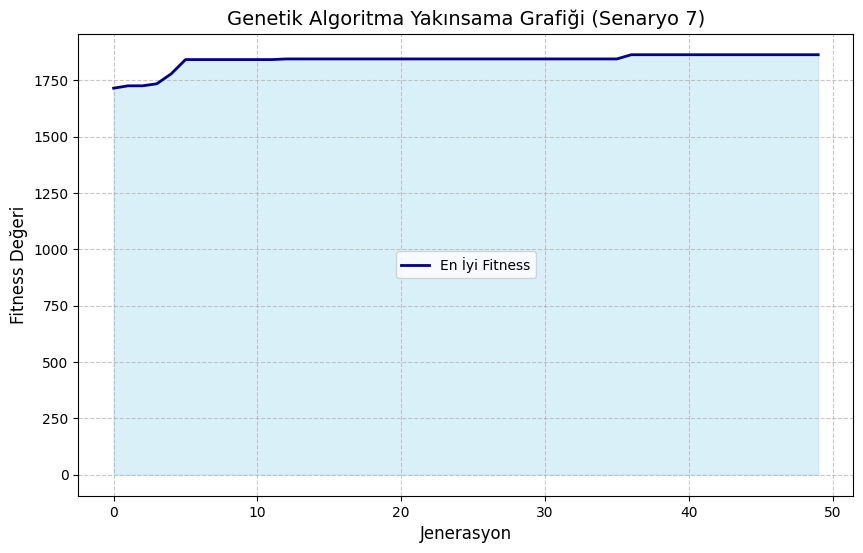

In [4]:
# --- SONUÇLARI YAZDIR ---
x1_opt = best_individual[0]
x2_opt = best_individual[1]

# Kısıt Kontrolü
constraint1 = (x1_opt + x2_opt) <= 100.01
constraint2 = x1_opt >= 24.99

print("=" * 60)
print(f"🎯 EN İYİ SONUÇ (Amaç Fonksiyonu Değeri): {best_score:.4f}")
print("=" * 60)
print(f"Reaktif A Oranı (x1): %{x1_opt:.4f}")
print(f"Reaktif B Oranı (x2): %{x2_opt:.4f}")
print("-" * 30)
print(f"KISIT 1 (x1 + x2 ≤ 100): {x1_opt + x2_opt:.2f} -> {'✅ Uygun' if constraint1 else '❌ İHLAL'}")
print(f"KISIT 2 (x1 ≥ 25)      : {x1_opt:.2f}       -> {'✅ Uygun' if constraint2 else '❌ İHLAL'}")

# --- GRAFİK ---
plt.figure(figsize=(10, 6))
plt.plot(best_scores_history, color='darkblue', linewidth=2, label='En İyi Fitness')
plt.fill_between(range(len(best_scores_history)), best_scores_history, color='skyblue', alpha=0.3)
plt.title('Genetik Algoritma Yakınsama Grafiği (Senaryo 7)', fontsize=14)
plt.xlabel('Jenerasyon', fontsize=12)
plt.ylabel('Fitness Değeri', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()